# Roulette Simulation and Profit Analysis

Roulette is a popular casino game played with a wheel that has numbered slots colored red, black, or green. In American roulette, the wheel has 38 slots: 18 red slots, 18 black slots, and 2 green slots labeled "0" and "00."

Players can place various types of bets, including betting on whether the outcome will be a red or black slot. In this exercise, we focus on a simple bet: betting on black.

If you place a bet on black and the outcome is indeed black, you win and double your money. However, if the outcome is red or green, you lose the amount you bet. For example, if you bet 1 dollar on black and win, you gain 1 dollar. If you lose, you forfeit your 1-dollar bet.

Since there are three colors, the probability of landing on black is not exactly $\frac{1}{2}$, but rather: $\frac{18}{38} = \frac{9}{19}$

### Import Required Libraries

In [1]:
import math
import random
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

### 1. Function that simulates the game for 𝑁 rounds

In [2]:
def roulette_simulation(N):
    total_earned = 0
    for _ in range(N):
        number = random.randint(1, 38)
        if number <= 18:
            total_earned += 1
        else:
            total_earned -= 1
            
    return total_earned


In [4]:
N = 1000
earnings = roulette_simulation(N)
print(earnings)

-22


### 2. Monte Carlo Simulation

Results for N = 10:
  Sample Mean:                     -0.517
  Sample Std Dev (Spread of S_N):  3.154
--------------------------------------------------
Results for N = 25:
  Sample Mean:                     -1.298
  Sample Std Dev (Spread of S_N):  4.978
--------------------------------------------------
Results for N = 100:
  Sample Mean:                     -5.210
  Sample Std Dev (Spread of S_N):  9.990
--------------------------------------------------
Results for N = 1000:
  Sample Mean:                     -52.669
  Sample Std Dev (Spread of S_N):  31.443
--------------------------------------------------


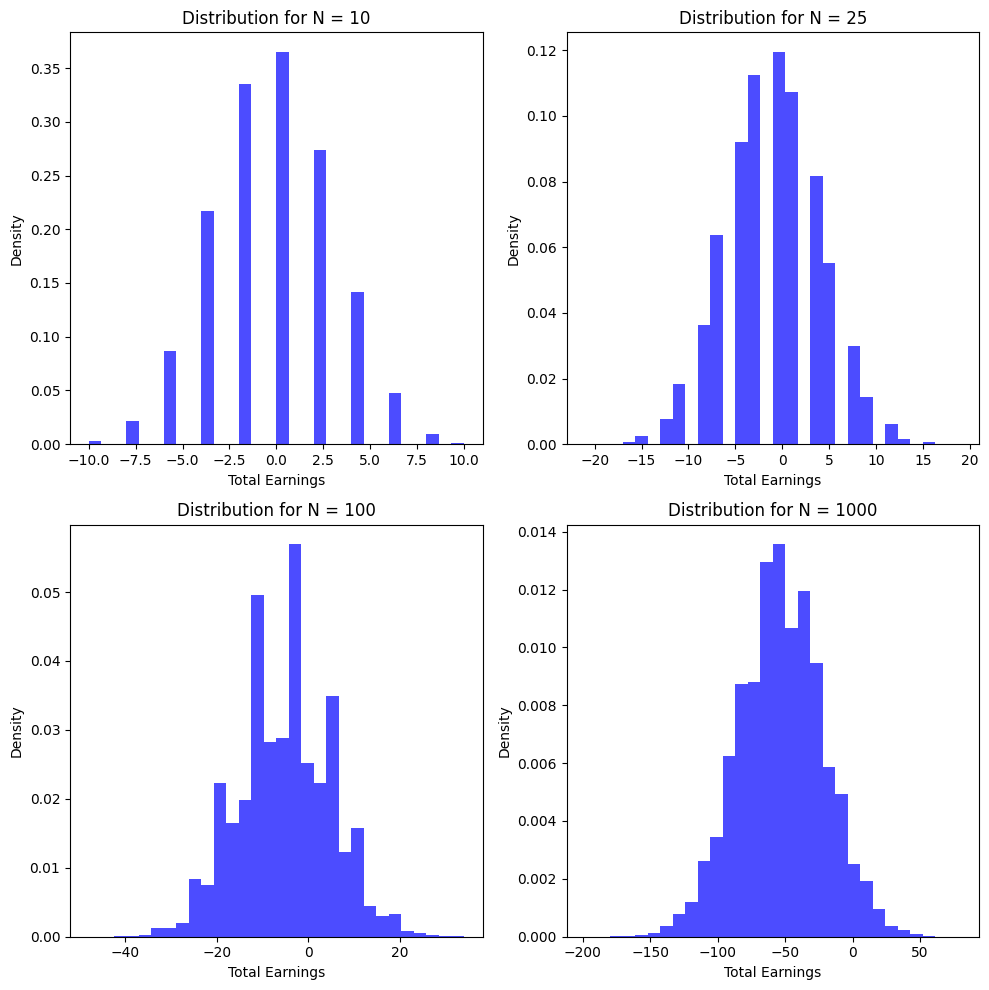

In [11]:
num_simulations = 100000
N_values = [10, 25, 100, 1000]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i in range(len(N_values)):
    results = [roulette_simulation(N_values[i]) for _ in range(num_simulations)]
    results = np.array(results)

    ax = axes[i]
    ax.hist(results, bins=30, density=True, alpha=0.7, color='blue')
    ax.set_title(f"Distribution for N = {N_values[i]}")
    ax.set_xlabel("Total Earnings")
    ax.set_ylabel("Density")
    
    sample_mean = np.mean(results)
    sample_std = np.std(results, ddof=1)
    
    print(f"Results for N = {N_values[i]}:")
    print(f"  Sample Mean:                     {sample_mean:.3f}")
    print(f"  Sample Std Dev (Spread of S_N):  {sample_std:.3f}")
    print("-" * 50)
    
plt.tight_layout()
plt.show()

### 3. Previous simulation but for the average winnings

Results for N = 10:
  Sample Mean:                     -0.051
  Sample Std Dev (Spread of S_N/N):  0.31490
--------------------------------------------------
Results for N = 25:
  Sample Mean:                     -0.053
  Sample Std Dev (Spread of S_N/N):  0.20010
--------------------------------------------------
Results for N = 100:
  Sample Mean:                     -0.053
  Sample Std Dev (Spread of S_N/N):  0.10005
--------------------------------------------------
Results for N = 1000:
  Sample Mean:                     -0.053
  Sample Std Dev (Spread of S_N/N):  0.03160
--------------------------------------------------


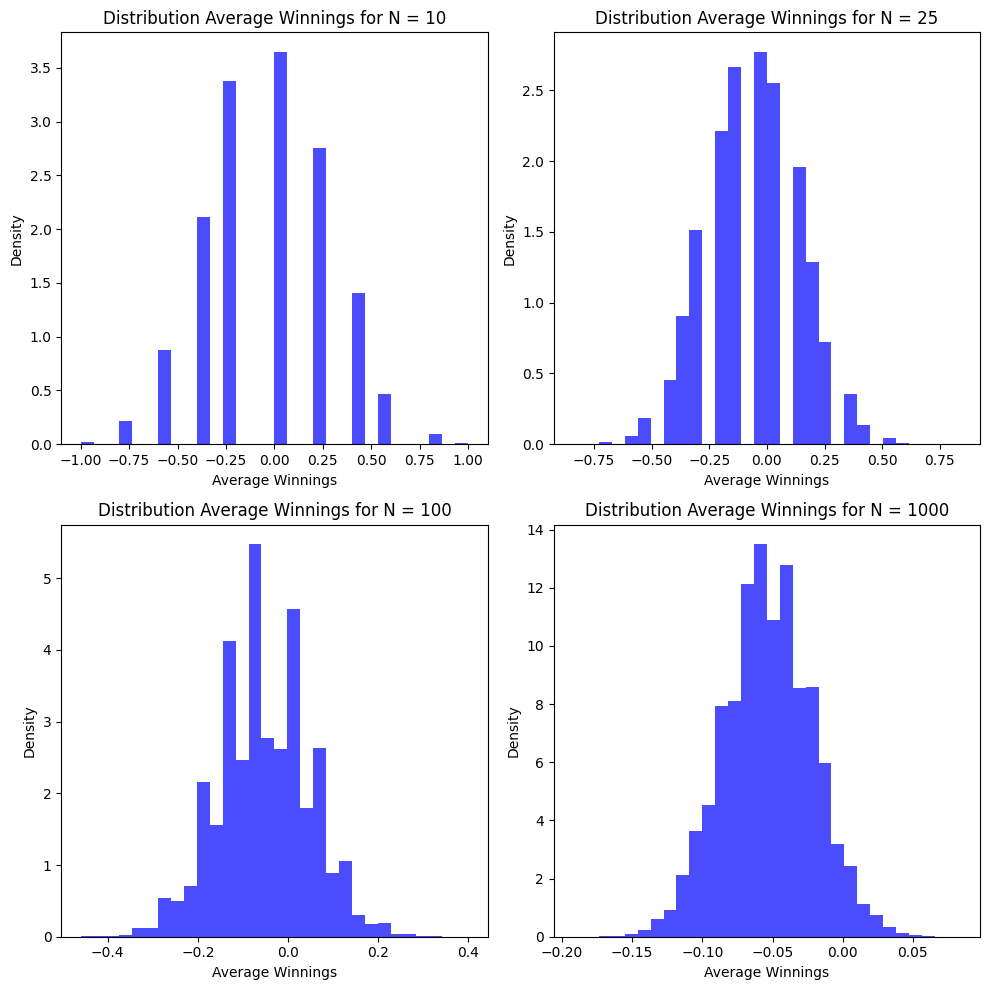

In [12]:
num_simulations = 100000
N_values = [10, 25, 100, 1000]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i in range(len(N_values)):
    
    results = [roulette_simulation(N_values[i])/N_values[i] for _ in range(num_simulations)]
    results = np.array(results)

    ax = axes[i]
    ax.hist(results, bins=30, density=True, alpha=0.7, color='blue')
    ax.set_title(f"Distribution Average Winnings for N = {N_values[i]}")
    ax.set_xlabel("Average Winnings")
    ax.set_ylabel("Density")
    
    sample_mean = np.mean(results)
    sample_std = np.std(results, ddof=1)
    
    print(f"Results for N = {N_values[i]}:")
    print(f"  Sample Mean:                     {sample_mean:.3f}")
    print(f"  Sample Std Dev (Spread of S_N/N):  {sample_std:.5f}") 
    print("-" * 50)
    
plt.tight_layout()
plt.show()

### 4. Compare theoretical values with Monte Carlo simulation results

In [13]:
num_simulations = 100000
N_values = [10, 25, 100, 1000]

Expected_value_single = -1 / 19  # E(X) = (18/38)*1 + (20/38)*(-1)
Variance_single = 360 / 361  # Var(X) = 1 - (-1/19)^2

for i in range(len(N_values)):
    results = [roulette_simulation(N_values[i]) for _ in range(num_simulations)]
    results = np.array(results)

    sample_mean = np.mean(results)
    sample_std = np.std(results, ddof=1)
    
    theoretical_mean = N_values[i] * Expected_value_single
    theoretical_std = np.sqrt(N_values[i] * Variance_single)
    
    print(f"Results for N = {N_values[i]}:")
    print(f"  Sample Mean:                     {sample_mean:.3f}")
    print(f"  Theoretical Mean:                {theoretical_mean:.3f}")
    print(f"  Sample Standard Deviation:        {sample_std:.3f}")     
    print(f"  Theoretical Standard Deviation:   {theoretical_std:.3f}") 
    print("-" * 50)

Results for N = 10:
  Sample Mean:                     -0.537
  Theoretical Mean:                -0.526
  Sample Standard Deviation:        3.156
  Theoretical Standard Deviation:   3.158
--------------------------------------------------
Results for N = 25:
  Sample Mean:                     -1.324
  Theoretical Mean:                -1.316
  Sample Standard Deviation:        5.006
  Theoretical Standard Deviation:   4.993
--------------------------------------------------
Results for N = 100:
  Sample Mean:                     -5.250
  Theoretical Mean:                -5.263
  Sample Standard Deviation:        10.017
  Theoretical Standard Deviation:   9.986
--------------------------------------------------
Results for N = 1000:
  Sample Mean:                     -52.552
  Theoretical Mean:                -52.632
  Sample Standard Deviation:        31.531
  Theoretical Standard Deviation:   31.579
--------------------------------------------------


### 5. CLT Approximation vs Monte Carlo Estimate

For $N = 25$:

- *Mean of $S_N$*:  
  $$
    \mu = E[S_N] = N \times E[X_i] = 25 \times \left(-\frac{1}{19}\right) = -\frac{25}{19}
  $$

- *Standard Deviation of $S_N$*:  
  $$
    \sigma = \sqrt{N \times \mathrm{Var}(X_i)} = \sqrt{25 \times \frac{360}{361}} = 5 \sqrt{\frac{360}{361}}
  $$

We want the probability that **the casino loses money**, which means:

$$
P(\text{casino loses}) = P(S_N > 0).
$$

By the Central Limit Theorem, for moderate $N$, $S_N$ is approximately normal with mean $\mu$ and standard deviation $\sigma$.

$$
P(S_N > 0) 
= P\left(\frac{S_N - \mu}{\sigma} > \frac{0 - \mu}{\sigma}\right) 
= 1 - \Phi\!\Bigl(\frac{0 - \mu}{\sigma}\Bigr)
$$


In [ ]:
N = 25
mu = N * Expected_value_single
sigma = math.sqrt(N * Variance_single)

z_value = (0 - mu) / sigma
clt_probability = 1 - norm.cdf(z_value)

print(f"CLT Approximation: {clt_probability:.5f}")

def monte_carlo_estimate(N, num_simulations):
    count_casino_loses = 0
    for _ in range(num_simulations):
        s = roulette_simulation(N)
        if s > 0:
            count_casino_loses += 1
    return count_casino_loses / num_simulations

mc_probability = monte_carlo_estimate(N, num_simulations)

print(f"Monte Carlo Estimate: {mc_probability:.5f}")

CLT Approximation: 0.39607
Monte Carlo Estimate: 0.39373


### 6. Plot the probability that the casino loses money

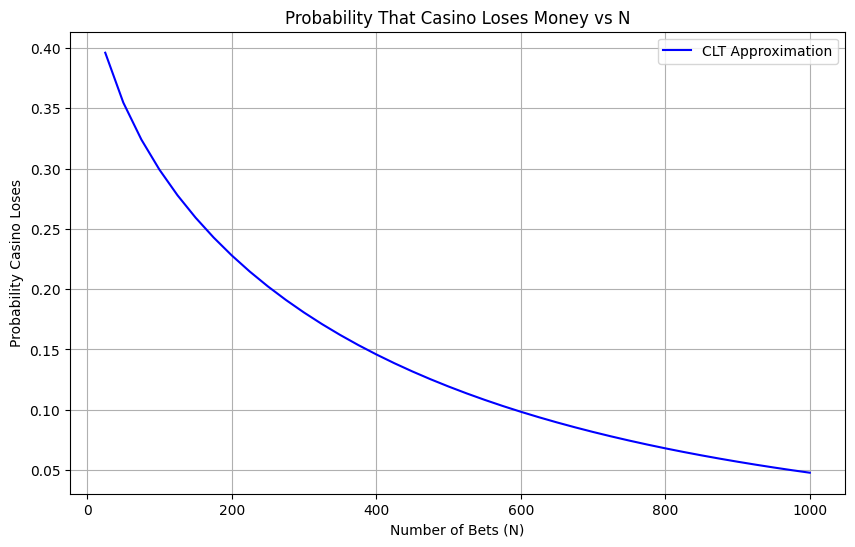

In [15]:
N_values = np.arange(25, 1001, 25)  # Values of N from 25 to 1000 in steps of 25

clt_probabilities = []
mc_probabilities = []

for N in N_values:
    mu = N * Expected_value_single
    sigma = math.sqrt(N * Variance_single)
    z_value = (0 - mu) / sigma
    clt_prob = 1 - norm.cdf(z_value)
    clt_probabilities.append(clt_prob)
    
    ### uncomment if you want to see Monte Carlo Estimate ###
    # mc_prob = monte_carlo_estimate(N, num_simulations)
    # mc_probabilities.append(mc_prob)

plt.figure(figsize=(10, 6))
plt.plot(N_values, clt_probabilities, label="CLT Approximation", color='blue')
### uncomment if you want to see Monte Carlo Estimate ###
# plt.plot(N_values, mc_probabilities, label="Monte Carlo Estimate", color='red')
plt.xlabel("Number of Bets (N)")
plt.ylabel("Probability Casino Loses")
plt.title("Probability That Casino Loses Money vs N")
plt.legend()
plt.grid()
plt.show()

# Predicting the Outcome of the 2016 USA Presidential Election

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import math
import seaborn as sns
from scipy.interpolate import make_interp_spline
import warnings
import scipy.stats as stats

# Style
sns.set_style("whitegrid")
sns.set_palette("colorblind")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
warnings.filterwarnings("ignore")

SEED=42
np.random.seed(SEED)

## Data

In [2]:
df = pd.read_csv('2016-general-election-trump-vs-clinton.csv')

In [3]:
df.head()

,Pollster,Start Date,End Date,Entry Date/Time (ET),Number of Observations,Population,Mode,Trump,Clinton,Other,Undecided,Pollster URL,Source URL,Partisan,Affiliation,Question Text,Question Iteration
0,Insights West,2016-11-04,2016-11-07,2016-11-08T12:16:30Z,940.0,Likely Voters,Internet,41.0,45.0,2.0,8.0,http://elections.huffingtonpost.com/pollster/p...,http://www.insightswest.com/news/clinton-is-ah...,Nonpartisan,NaN,"As you may know, there will be a presidential ...",1
1,Insights West,2016-11-04,2016-11-07,2016-11-08T12:16:30Z,NaN,Likely Voters - Democrat,Internet,6.0,89.0,0.0,4.0,http://elections.huffingtonpost.com/pollster/p...,http://www.insightswest.com/news/clinton-is-ah...,Nonpartisan,NaN,"As you may know, there will be a presidential ...",1
2,Insights West,2016-11-04,2016-11-07,2016-11-08T12:16:30Z,NaN,Likely Voters - Republican,Internet,82.0,7.0,2.0,6.0,http://elections.huffingtonpost.com/pollster/p...,http://www.insightswest.com/news/clinton-is-ah...,Nonpartisan,NaN,"As you may know, there will be a presidential ...",1
3,Insights West,2016-11-04,2016-11-07,2016-11-08T12:16:30Z,NaN,Likely Voters - independent,Internet,38.0,43.0,4.0,7.0,http://elections.huffingtonpost.com/pollster/p...,http://www.insightswest.com/news/clinton-is-ah...,Nonpartisan,NaN,"As you may know, there will be a presidential ...",1
4,IBD/TIPP,2016-11-04,2016-11-07,2016-11-08T12:10:06Z,1107.0,Likely Voters,Live Phone,43.0,41.0,4.0,5.0,http://elections.huffingtonpost.com/pollster/p...,http://www.investors.com/politics/ibd-tipp-pre...,Nonpartisan,NaN,NaN,1


### Data Exploration

In [4]:
print(f"Total rows in dataset: {len(df):,}")

Total rows in dataset: 1,522


In [5]:
print(f"Columns: {list(df.columns)}")

Columns: ['Pollster', 'Start Date', 'End Date', 'Entry Date/Time (ET)', 'Number of Observations', 'Population', 'Mode', 'Trump', 'Clinton', 'Other', 'Undecided', 'Pollster URL', 'Source URL', 'Partisan', 'Affiliation', 'Question Text', 'Question Iteration']


In [6]:
print("\nData types:")
df.dtypes


Data types:


Pollster                   object
Start Date                 object
End Date                   object
Entry Date/Time (ET)       object
Number of Observations    float64
Population                 object
Mode                       object
Trump                     float64
Clinton                   float64
Other                     float64
Undecided                 float64
Pollster URL               object
Source URL                 object
Partisan                   object
Affiliation                object
Question Text              object
Question Iteration          int64
dtype: object

In [7]:
print("\nMissing values:")
print(df.isna().sum())


Missing values:
Pollster                     0
Start Date                   0
End Date                     0
Entry Date/Time (ET)         0
Number of Observations     509
Population                   0
Mode                         0
Trump                        0
Clinton                      0
Other                      424
Undecided                   62
Pollster URL                 0
Source URL                   0
Partisan                     0
Affiliation               1434
Question Text              861
Question Iteration           0
dtype: int64


## Data Cleaning

###  1. Remove rows with missing `Number of Observations`

In [8]:
initial_count = len(df)
df = df.dropna(subset=['Number of Observations'])
print(f"Removed {initial_count - len(df):,} rows with missing 'Number of Observations'")

Removed 509 rows with missing 'Number of Observations'


### 2. Filter for national polls only (remove subgroups)

In [9]:
initial_count = len(df)
df = df[df['Affiliation'].isnull()]
print(f"Removed {initial_count - len(df):,} subgroup rows (keeping only national polls)")


Removed 44 subgroup rows (keeping only national polls)


### 3. Convert date columns

In [10]:
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])
df['Entry Date/Time (ET)'] = pd.to_datetime(df['Entry Date/Time (ET)'])

### 4. Calculate poll duration

In [11]:
df['Poll Duration'] = (df['End Date'] - df['Start Date']).dt.days + 1

In [ ]:
print(f"\nFinal dataset size: {len(df):,} polls")
print(f"Date range: {df['Start Date'].min().date()} to {df['Start Date'].max().date()}")


Final dataset size: 969 polls
Date range: 2015-05-19 to 2016-11-04


## EDA Visualizations

### 1. Poll Distribution Over Time

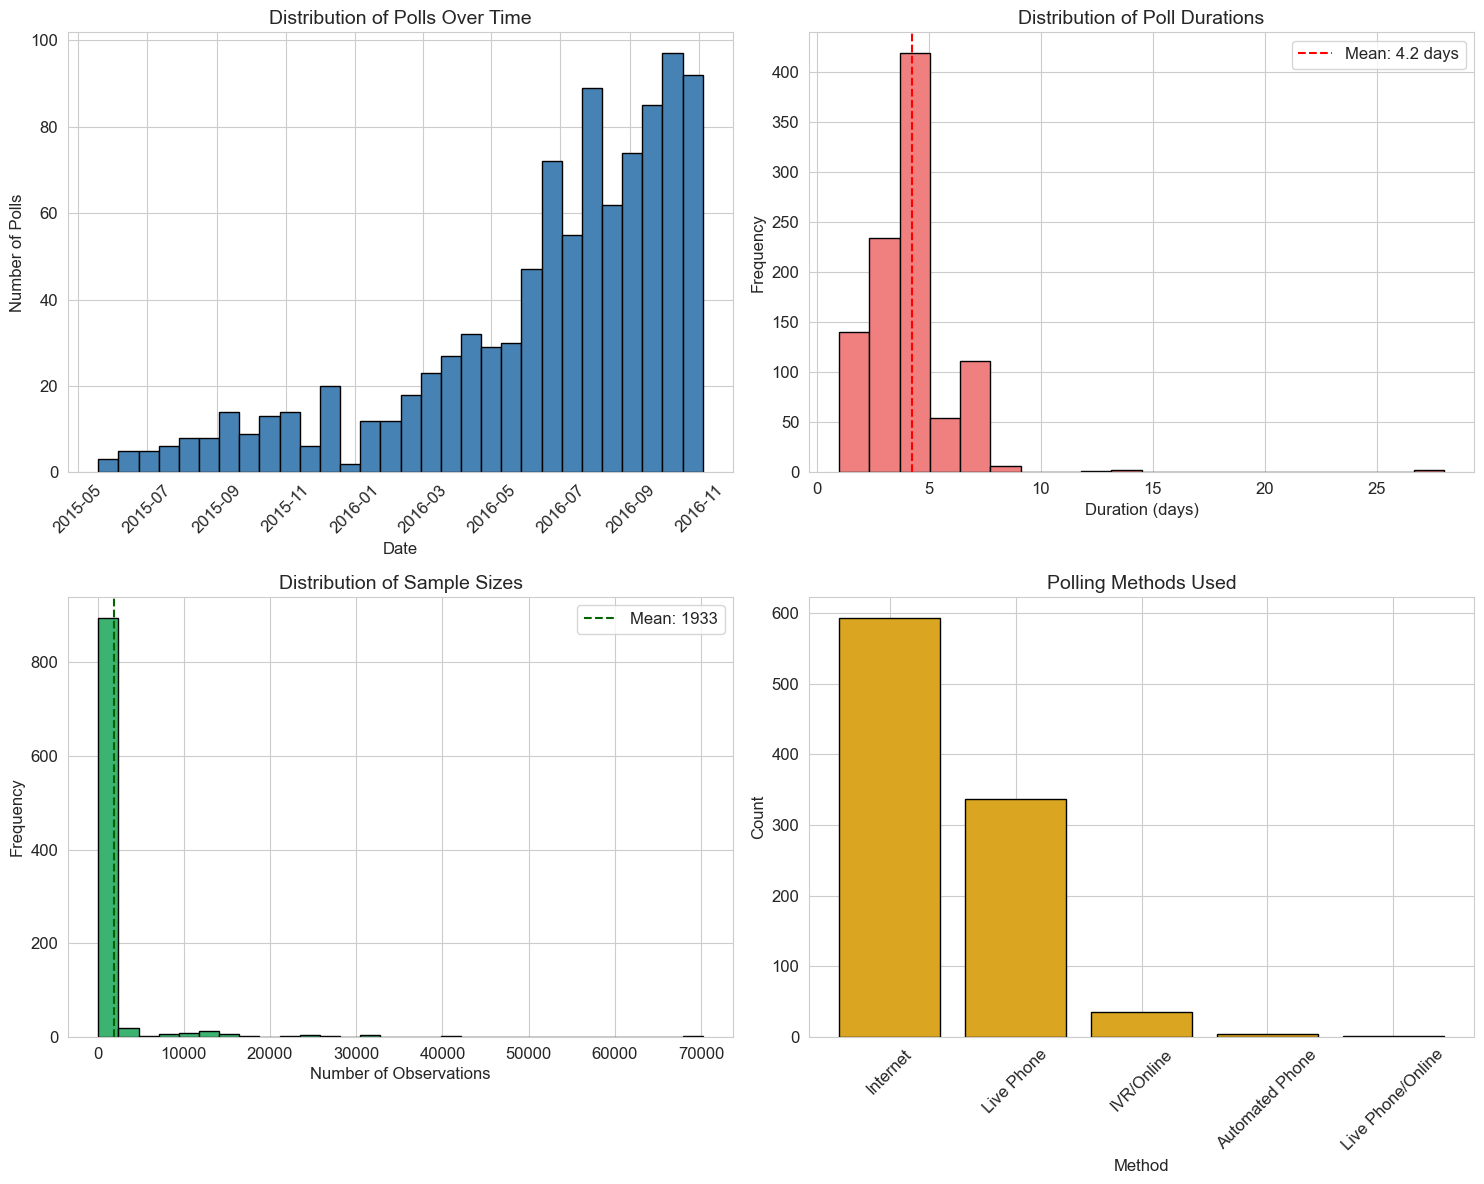

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Poll frequency over time
df['Start Date'].hist(bins=30, ax=axes[0, 0], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Polls Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Number of Polls')
axes[0, 0].tick_params(axis='x', rotation=45)

# Poll duration distribution
df['Poll Duration'].hist(bins=20, ax=axes[0, 1], color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Distribution of Poll Durations')
axes[0, 1].set_xlabel('Duration (days)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df['Poll Duration'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {df["Poll Duration"].mean():.1f} days')
axes[0, 1].legend()

# Sample size distribution
df['Number of Observations'].hist(bins=30, ax=axes[1, 0], color='mediumseagreen', edgecolor='black')
axes[1, 0].set_title('Distribution of Sample Sizes')
axes[1, 0].set_xlabel('Number of Observations')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(df['Number of Observations'].mean(), color='darkgreen', linestyle='--',
                   label=f'Mean: {df["Number of Observations"].mean():.0f}')
axes[1, 0].legend()

# Polling mode distribution
mode_counts = df['Mode'].value_counts()
axes[1, 1].bar(mode_counts.index, mode_counts.values, color='goldenrod', edgecolor='black')
axes[1, 1].set_title('Polling Methods Used')
axes[1, 1].set_xlabel('Method')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2. Support Distribution Comparison

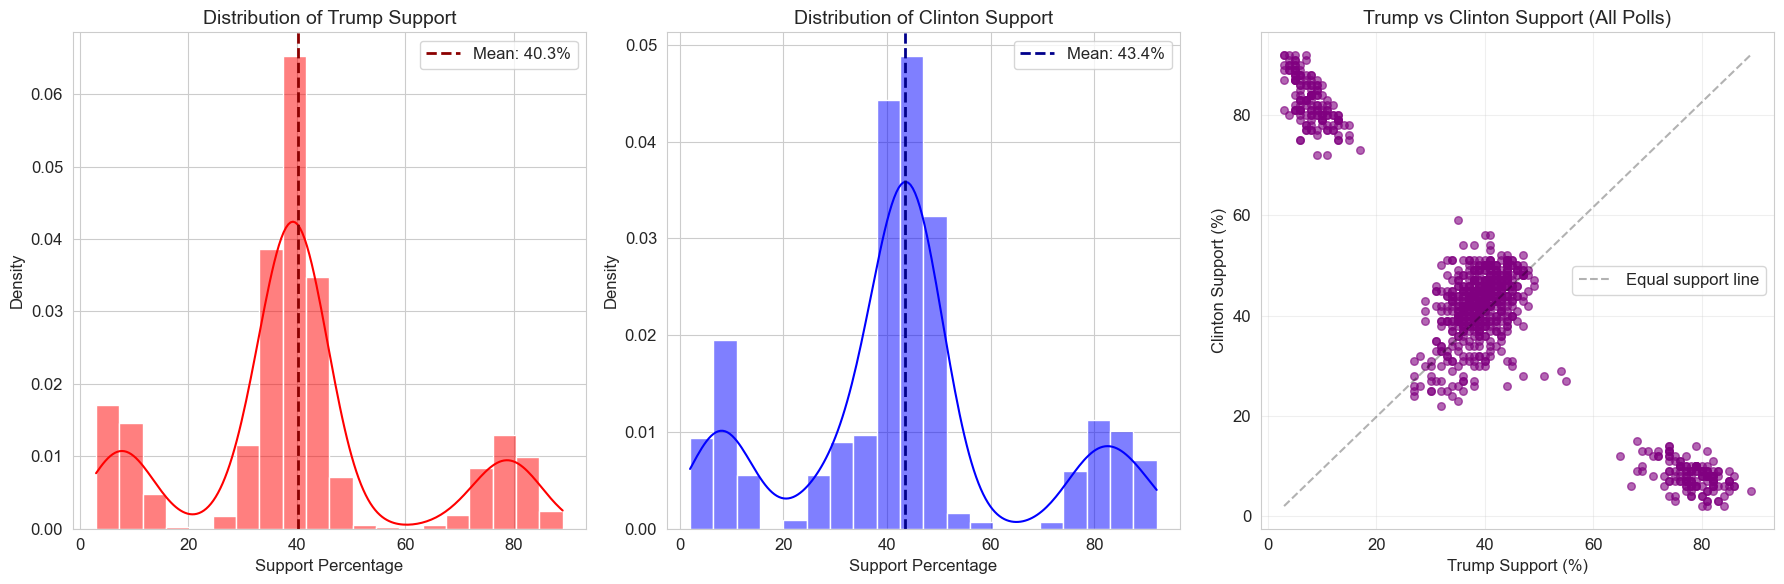

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Histograms with KDE
sns.histplot(df['Trump'], kde=True, ax=axes[0], color='red', bins=20, stat='density')
axes[0].axvline(df['Trump'].mean(), color='darkred', linestyle='--', linewidth=2,
                label=f'Mean: {df["Trump"].mean():.1f}%')
axes[0].set_title('Distribution of Trump Support')
axes[0].set_xlabel('Support Percentage')
axes[0].legend()

sns.histplot(df['Clinton'], kde=True, ax=axes[1], color='blue', bins=20, stat='density')
axes[1].axvline(df['Clinton'].mean(), color='darkblue', linestyle='--', linewidth=2,
                label=f'Mean: {df["Clinton"].mean():.1f}%')
axes[1].set_title('Distribution of Clinton Support')
axes[1].set_xlabel('Support Percentage')
axes[1].legend()

# Scatter plot of Trump vs Clinton support
axes[2].scatter(df['Trump'], df['Clinton'], alpha=0.6, color='purple', s=30)
axes[2].plot([df['Trump'].min(), df['Trump'].max()], 
             [df['Clinton'].min(), df['Clinton'].max()], 
             'k--', alpha=0.3, label='Equal support line')
axes[2].set_xlabel('Trump Support (%)')
axes[2].set_ylabel('Clinton Support (%)')
axes[2].set_title('Trump vs Clinton Support (All Polls)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Pollster Analysis

In [15]:
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Top 10 Most Active Polling Organizations', 
                   'Polling Accuracy and Consistency (Organizations with ≥5 Polls)'),
    vertical_spacing=0.15,
    row_heights=[0.4, 0.6]
)

top_pollsters = df['Pollster'].value_counts().head(10)

hover_texts = []
for pollster in top_pollsters.index:
    pollster_data = df[df['Pollster'] == pollster]
    methods = pollster_data['Mode'].value_counts()
    method_str = "<br>".join([f"{method}: {count} polls" for method, count in methods.items()])
    avg_trump = pollster_data['Trump'].mean()
    avg_clinton = pollster_data['Clinton'].mean()
    hover_texts.append(
        f"<b>{pollster}</b><br>"
        f"Total Polls: {top_pollsters[pollster]}<br>"
        f"Avg Trump: {avg_trump:.1f}%<br>"
        f"Avg Clinton: {avg_clinton:.1f}%<br>"
        f"Margin: {avg_clinton - avg_trump:+.1f}%<br>"
        f"<br><b>Methodology:</b><br>{method_str}"
    )

fig.add_trace(
    go.Bar(
        y=top_pollsters.index,
        x=top_pollsters.values,
        orientation='h',
        marker_color='teal',
        marker_line_color='black',
        marker_line_width=1,
        text=top_pollsters.values,
        textposition='outside',
        hovertext=hover_texts,
        hoverinfo='text',
        name='Number of Polls'
    ),
    row=1, col=1
)

fig.update_xaxes(title_text="Number of Polls Conducted", row=1, col=1)
fig.update_yaxes(title_text="Polling Organization", autorange="reversed", row=1, col=1)

pollster_stats = df.groupby('Pollster').agg({
    'Trump': ['mean', 'std', 'count'],
    'Clinton': ['mean', 'std', 'count'],
    'Mode': lambda x: x.mode().iloc[0] if not x.mode().empty else 'Mixed'
}).round(1)

reliable_pollsters = pollster_stats[pollster_stats[('Trump', 'count')] >= 5]
pollster_names = reliable_pollsters.index

trump_means = reliable_pollsters[('Trump', 'mean')].values
clinton_means = reliable_pollsters[('Clinton', 'mean')].values
trump_stds = reliable_pollsters[('Trump', 'std')].values
clinton_stds = reliable_pollsters[('Clinton', 'std')].values
poll_counts = reliable_pollsters[('Trump', 'count')].values
primary_modes = reliable_pollsters[('Mode', '<lambda>')].values

hover_texts_trump = []
hover_texts_clinton = []

for i, pollster in enumerate(pollster_names):
    pollster_data = df[df['Pollster'] == pollster]

    method_counts = pollster_data['Mode'].value_counts()
    method_dist = "<br>".join([f"{method}: {count}" for method, count in method_counts.items()])

    start_date = pollster_data['Start Date'].min().strftime('%Y-%m-%d')
    end_date = pollster_data['End Date'].max().strftime('%Y-%m-%d')

    trump_min = pollster_data['Trump'].min()
    trump_max = pollster_data['Trump'].max()
    clinton_min = pollster_data['Clinton'].min()
    clinton_max = pollster_data['Clinton'].max()
    margin = clinton_means[i] - trump_means[i]
    
    hover_texts_trump.append(
        f"<b>{pollster} - Trump</b><br>"
        f"Average: {trump_means[i]:.1f}%<br>"
        f"Std Dev: ±{trump_stds[i]:.1f}%<br>"
        f"Range: {trump_min:.1f}% - {trump_max:.1f}%<br>"
        f"Number of Polls: {poll_counts[i]}<br>"
        f"Primary Method: {primary_modes[i]}<br>"
        f"Polling Period: {start_date} to {end_date}<br>"
        f"Clinton Lead: {margin:+.1f}%<br>"
        f"<br><b>Methodology Distribution:</b><br>{method_dist}"
    )
    
    hover_texts_clinton.append(
        f"<b>{pollster} - Clinton</b><br>"
        f"Average: {clinton_means[i]:.1f}%<br>"
        f"Std Dev: ±{clinton_stds[i]:.1f}%<br>"
        f"Range: {clinton_min:.1f}% - {clinton_max:.1f}%<br>"
        f"Number of Polls: {poll_counts[i]}<br>"
        f"Primary Method: {primary_modes[i]}<br>"
        f"Polling Period: {start_date} to {end_date}<br>"
        f"Clinton Lead: {margin:+.1f}%<br>"
        f"<br><b>Methodology Distribution:</b><br>{method_dist}"
    )

fig.add_trace(
    go.Bar(
        x=pollster_names,
        y=trump_means,
        name='Trump',
        marker_color='red',
        opacity=0.8,
        error_y=dict(
            type='data',
            array=trump_stds,
            visible=True,
            thickness=1.5,
            width=3
        ),
        hovertext=hover_texts_trump,
        hoverinfo='text',
        text=[f"{val:.1f}%" for val in trump_means],
        textposition='outside'
    ),
    row=2, col=1
)

fig.add_trace(
    go.Bar(
        x=pollster_names,
        y=clinton_means,
        name='Clinton',
        marker_color='blue',
        opacity=0.8,
        error_y=dict(
            type='data',
            array=clinton_stds,
            visible=True,
            thickness=1.5,
            width=3
        ),
        hovertext=hover_texts_clinton,
        hoverinfo='text',
        text=[f"{val:.1f}%" for val in clinton_means],
        textposition='outside'
    ),
    row=2, col=1
)

fig.add_hline(
    y=50,
    line_dash="dash",
    line_color="gray",
    opacity=0.5,
    row=2, col=1
)

fig.update_xaxes(
    title_text="Polling Organization",
    tickangle=45,
    row=2, col=1
)
fig.update_yaxes(
    title_text="Average Support (%) ± Standard Deviation",
    row=2, col=1
)

fig.update_layout(
    height=900,
    showlegend=True,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.02
    ),
    hoverlabel=dict(
        bgcolor="white",
        font_size=12,
        font_family="Arial"
    ),
    title=dict(
        text="2016 Presidential Election Pollster Analysis",
        x=0.5,
        font=dict(size=20)
    )
)


fig.show()

# Methodology comparison

methodology_data = []
for pollster in reliable_pollsters.index:
    pollster_data = df[df['Pollster'] == pollster]
    for mode in pollster_data['Mode'].unique():
        mode_data = pollster_data[pollster_data['Mode'] == mode]
        methodology_data.append({
            'Pollster': pollster,
            'Method': mode,
            'Trump_Avg': mode_data['Trump'].mean(),
            'Clinton_Avg': mode_data['Clinton'].mean(),
            'Count': len(mode_data),
            'Margin': mode_data['Clinton'].mean() - mode_data['Trump'].mean()
        })

method_df = pd.DataFrame(methodology_data)

fig2 = px.scatter(
    method_df,
    x='Trump_Avg',
    y='Clinton_Avg',
    size='Count',
    color='Method',
    hover_name='Pollster',
    hover_data=['Method', 'Count', 'Margin'],
    title='Poll Results by Methodology Type',
    labels={
        'Trump_Avg': 'Average Trump Support (%)',
        'Clinton_Avg': 'Average Clinton Support (%)',
        'Method': 'Polling Method',
        'Count': 'Number of Polls'
    },
    size_max=30,
    color_discrete_sequence=px.colors.qualitative.Set1_r
)

fig2.add_shape(
    type="line",
    x0=30, y0=30,
    x1=50, y1=50,
    line=dict(color="gray", width=1, dash="dash")
)

fig2.add_annotation(
    x=45, y=45,
    text="Equal Support Line",
    showarrow=False,
    font=dict(size=10, color="gray")
)

fig2.update_layout(
    height=600,
    legend=dict(
        title="Polling Method",
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.02
    )
)

fig2.update_layout(
    title={
        'text': 'Poll Results by Methodology Type',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=20)
    },
    height=600,
    legend=dict(
        title="Polling Method",
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.02
    )
)

fig2.show()


print("\n" + "="*70)
print("INTERACTIVE FEATURES:")
print("="*70)
print("1. Hover over any bar to see:")
print("   - Pollster name and number of polls")
print("   - Average support and standard deviation")
print("   - Full range (min-max) of results")
print("   - Methodology distribution (phone, online, etc.)")
print("   - Polling period covered")
print("   - Clinton's lead margin")
print("\n2. Interactive controls:")
print("   - Zoom in/out with mouse wheel")
print("   - Pan by clicking and dragging")
print("   - Double-click to reset view")
print("   - Hover over legend items to highlight")
print("   - Click legend items to show/hide data")
print("="*70)



INTERACTIVE FEATURES:
1. Hover over any bar to see:
   - Pollster name and number of polls
   - Average support and standard deviation
   - Full range (min-max) of results
   - Methodology distribution (phone, online, etc.)
   - Polling period covered
   - Clinton's lead margin

2. Interactive controls:
   - Zoom in/out with mouse wheel
   - Pan by clicking and dragging
   - Double-click to reset view
   - Hover over legend items to highlight
   - Click legend items to show/hide data


## 1- 95% Confidence Interval for Democratic supporters


Poll Results:
   • Sample size: N = 100,000 voters
   • Democratic supporters: 48,007
   • Sample proportion: p̂ = 0.4801 (48.0%)
   • True proportion: p = 0.4800 (48.0%)

Derivation of 95% Confidence Interval:
   From CLT: (p̂ - p) / SE ~ N(0, 1)
   Where SE = √[p̂(1-p̂)/N]
   For 95% CI: P(-z ≤ (p̂-p)/SE ≤ z) = 0.95
   Rearranging: p̂ - z·SE ≤ p ≤ p̂ + z·SE

Computed Statistics:
   • Standard Error (SE): 0.001580
   • Z-score for 95%: z = 1.9600
   • Margin of Error: ±0.0031
   • 95% CI: [0.4770, 0.4832]
   • CI Width: 0.0062
   • Contains true p? YES


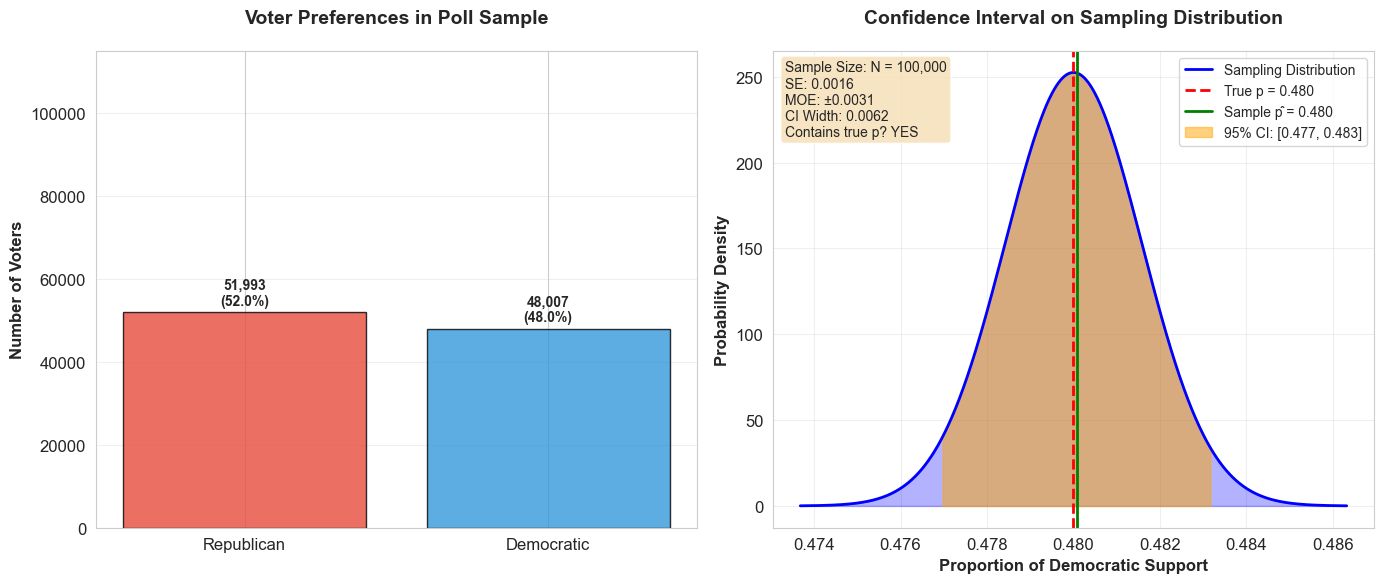


ANALYSIS: How Sample Size Affects Confidence Interval


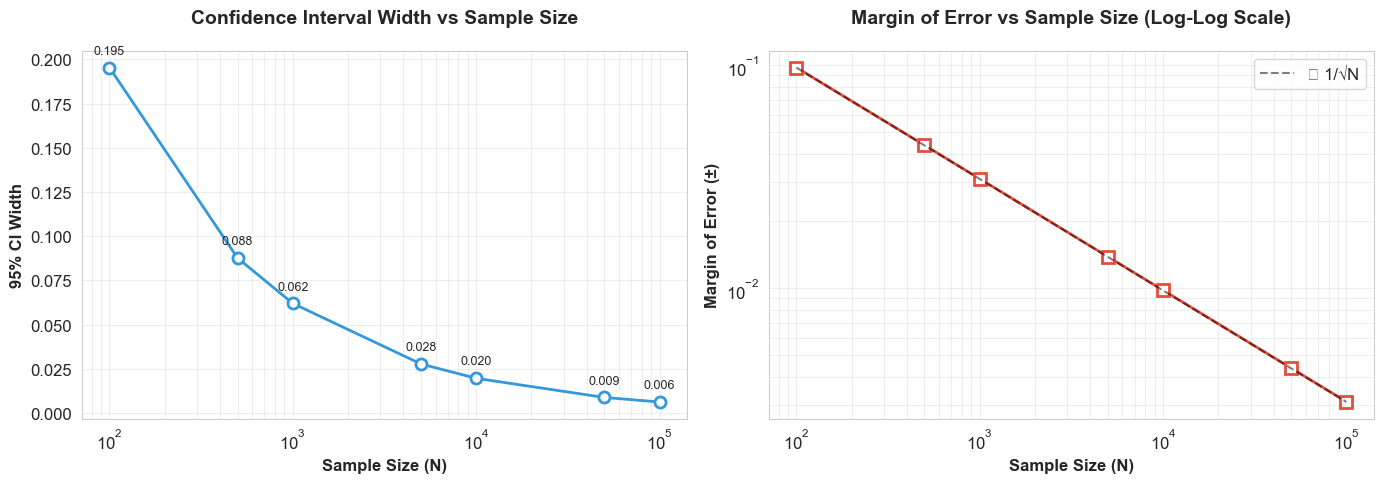

In [16]:
N = 100000
true_p = 0.48
confidence_level = 0.95

voters = np.random.binomial(1, true_p, N)
democratic_support = np.sum(voters)
p_hat = democratic_support / N

print(f"\nPoll Results:")
print(f"   • Sample size: N = {N:,} voters")
print(f"   • Democratic supporters: {democratic_support:,}")
print(f"   • Sample proportion: p̂ = {p_hat:.4f} ({p_hat:.1%})")
print(f"   • True proportion: p = {true_p:.4f} ({true_p:.1%})")

# Standard error
se = np.sqrt(p_hat * (1 - p_hat) / N)

# Z-score for given confidence level
z = stats.norm.ppf(1 - (1 - confidence_level) / 2)

# Confidence interval bounds
ci_lower = p_hat - z * se
ci_upper = p_hat + z * se
ci_width = ci_upper - ci_lower
contains_true = ci_lower <= true_p <= ci_upper

print("\nDerivation of 95% Confidence Interval:")
print("   From CLT: (p̂ - p) / SE ~ N(0, 1)")
print("   Where SE = √[p̂(1-p̂)/N]")
print("   For 95% CI: P(-z ≤ (p̂-p)/SE ≤ z) = 0.95")
print("   Rearranging: p̂ - z·SE ≤ p ≤ p̂ + z·SE")

print(f"\nComputed Statistics:")
print(f"   • Standard Error (SE): {se:.6f}")
print(f"   • Z-score for {confidence_level*100:.0f}%: z = {z:.4f}")
print(f"   • Margin of Error: ±{z*se:.4f}")
print(f"   • 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"   • CI Width: {ci_width:.4f}")
print(f"   • Contains true p? {'YES' if contains_true else 'NO'}")


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
categories = ['Republican', 'Democratic']
counts = [N - int(p_hat * N), int(p_hat * N)]
colors = ['#E74C3C', '#3498DB']

bars = ax1.bar(categories, counts, color=colors, alpha=0.8, edgecolor='black')
ax1.set_ylabel('Number of Voters', fontsize=12, fontweight='bold')
ax1.set_title('Voter Preferences in Poll Sample', fontsize=14, fontweight='bold', pad=20)

for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + N*0.01,
            f'{count:,}\n({count/N:.1%})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, N * 1.15)

ax2 = axes[1]
x_dist = np.linspace(true_p - 4*se, true_p + 4*se, 1000)
y_dist = stats.norm.pdf(x_dist, true_p, se)

ax2.plot(x_dist, y_dist, 'b-', linewidth=2, label='Sampling Distribution')
ax2.fill_between(x_dist, y_dist, alpha=0.3, color='blue')
ax2.axvline(true_p, color='red', linestyle='--', linewidth=2, label=f'True p = {true_p:.3f}')
ax2.axvline(p_hat, color='green', linestyle='-', linewidth=2, label=f'Sample p̂ = {p_hat:.3f}')

ci_x_fill = np.linspace(ci_lower, ci_upper, 100)
ci_y_fill = stats.norm.pdf(ci_x_fill, true_p, se)
ax2.fill_between(ci_x_fill, ci_y_fill, alpha=0.5, color='orange', 
                 label=f'95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]')

ax2.set_xlabel('Proportion of Democratic Support', fontsize=12, fontweight='bold')
ax2.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax2.set_title('Confidence Interval on Sampling Distribution', fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

info_text = (f'Sample Size: N = {N:,}\nSE: {se:.4f}\nMOE: ±{z*se:.4f}\n'
             f'CI Width: {ci_width:.4f}\nContains true p? {"YES" if contains_true else "NO"}')
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax2.text(0.02, 0.98, info_text, transform=ax2.transAxes, fontsize=10, verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("ANALYSIS: How Sample Size Affects Confidence Interval")
print("=" * 60)

sample_sizes = [100, 500, 1000, 5000, 10000, 50000, 100000]
ci_widths = []
margins_of_error = []

for size in sample_sizes:
    voters_temp = np.random.binomial(1, true_p, size)
    p_hat_temp = np.sum(voters_temp) / size
    se_temp = np.sqrt(p_hat_temp * (1 - p_hat_temp) / size)
    moe_temp = 1.96 * se_temp
    ci_widths.append(2 * moe_temp)
    margins_of_error.append(moe_temp)

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))

ax3.plot(sample_sizes, ci_widths, 'o-', linewidth=2, markersize=8, color='#3498DB', markerfacecolor='white', markeredgewidth=2)
ax3.set_xscale('log')
ax3.set_xlabel('Sample Size (N)', fontsize=12, fontweight='bold')
ax3.set_ylabel('95% CI Width', fontsize=12, fontweight='bold')
ax3.set_title('Confidence Interval Width vs Sample Size', fontsize=14, fontweight='bold', pad=20)
ax3.grid(True, alpha=0.3, which='both')

for s_n, width in zip(sample_sizes, ci_widths):
    ax3.annotate(f'{width:.3f}', xy=(s_n, width), xytext=(0, 10), textcoords='offset points', ha='center', fontsize=9)

ax4.loglog(sample_sizes, margins_of_error, 's-', linewidth=2, markersize=8, color='#E74C3C', markerfacecolor='white', markeredgewidth=2)
ax4.set_xlabel('Sample Size (N)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Margin of Error (±)', fontsize=12, fontweight='bold')
ax4.set_title('Margin of Error vs Sample Size (Log-Log Scale)', fontsize=14, fontweight='bold', pad=20)
ax4.grid(True, alpha=0.3, which='both')

ref_N = np.array([min(sample_sizes), max(sample_sizes)])
ref_moe = margins_of_error[0] / np.sqrt(ref_N / sample_sizes[0])
ax4.loglog(ref_N, ref_moe, 'k--', alpha=0.5, label='∝ 1/√N')
ax4.legend()

plt.tight_layout()
plt.show()


## 2- Monte Carlo Simulation for Confidence Interval

MONTE CARLO SIMULATION RESULTS
True population proportion (p): 0.470
Sample size (N): 30
Number of simulated polls: 10,000
Proportion of CIs containing true p: 0.9317
Expected proportion: 0.9500


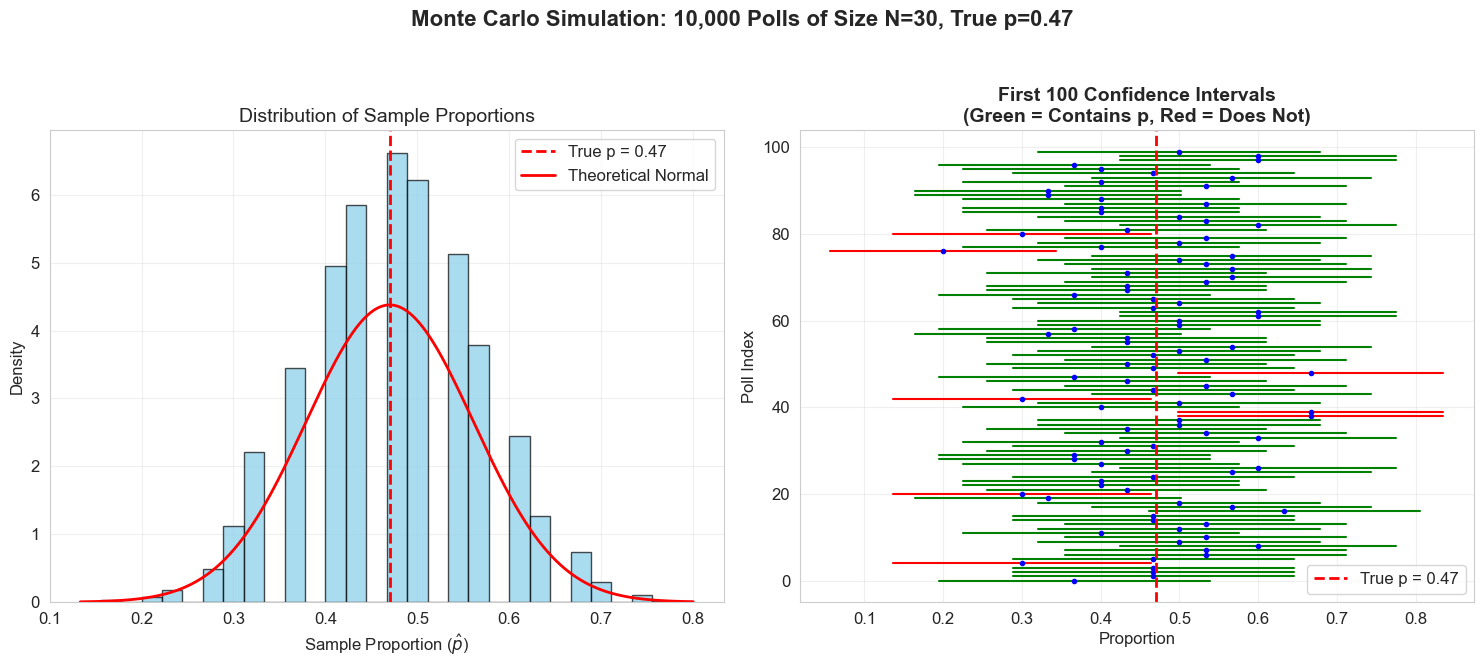


ADDITIONAL STATISTICS
Mean CI width: 0.3511
Minimum CI width: 0.2433
Maximum CI width: 0.3578


In [17]:
def simulate_confidence_intervals(p, N, num_iterations, seed=42):
    np.random.seed(seed)
    z_score = 1.96
    
    p_hats = np.zeros(num_iterations)
    ci_lowers = np.zeros(num_iterations)
    ci_uppers = np.zeros(num_iterations)
    captures = np.zeros(num_iterations, dtype=bool)
    
    for i in range(num_iterations):
        voters = np.random.binomial(1, p, N)
        p_hat = np.mean(voters)
        p_hats[i] = p_hat
        se = np.sqrt(p_hat * (1 - p_hat) / N)
        me = z_score * se
        ci_lower = p_hat - me
        ci_upper = p_hat + me
        ci_lowers[i] = ci_lower
        ci_uppers[i] = ci_upper
        captures[i] = (ci_lower <= p <= ci_upper)

    capture_proportion = np.mean(captures)
    return capture_proportion, p_hats, ci_lowers, ci_uppers, captures

p = 0.47
N = 30
num_iterations = 10000

capture_proportion, p_hats, ci_lowers, ci_uppers, captures = simulate_confidence_intervals(
    p, N, num_iterations
)

ci_widths = ci_uppers - ci_lowers

print("=" * 60)
print("MONTE CARLO SIMULATION RESULTS")
print("=" * 60)
print(f"True population proportion (p): {p:.3f}")
print(f"Sample size (N): {N}")
print(f"Number of simulated polls: {num_iterations:,}")
print(f"Proportion of CIs containing true p: {capture_proportion:.4f}")
print(f"Expected proportion: 0.9500")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle(f'Monte Carlo Simulation: {num_iterations:,} Polls of Size N={N}, True p={p}', 
             fontsize=16, fontweight='bold')

ax1 = axes[0]
ax1.hist(p_hats, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(x=p, color='red', linestyle='--', linewidth=2, label=f'True p = {p}')

x = np.linspace(min(p_hats), max(p_hats), 1000)
theoretical_std = np.sqrt(p * (1 - p) / N)
ax1.plot(x, stats.norm.pdf(x, p, theoretical_std), 'r-', linewidth=2, label='Theoretical Normal')

ax1.set_xlabel('Sample Proportion ($\hat{p}$)')
ax1.set_ylabel('Density')
ax1.set_title('Distribution of Sample Proportions')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
n_show = 100
colors = ['green' if cap else 'red' for cap in captures[:n_show]]

for i in range(n_show):
    ax2.plot([ci_lowers[i], ci_uppers[i]], [i, i], color=colors[i], linewidth=1.5)
    ax2.plot(p_hats[i], i, 'o', color='blue', markersize=3)

ax2.axvline(x=p, color='red', linestyle='--', linewidth=2, label=f'True p = {p}')
ax2.set_xlabel('Proportion')
ax2.set_ylabel('Poll Index')
ax2.set_title(f'First {n_show} Confidence Intervals\n(Green = Contains p, Red = Does Not)', 
              fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\nADDITIONAL STATISTICS")
print("=" * 60)
print(f"Mean CI width: {np.mean(ci_widths):.4f}")
print(f"Minimum CI width: {np.min(ci_widths):.4f}")
print(f"Maximum CI width: {np.max(ci_widths):.4f}")
print("=" * 60)


##  3- Data Loading

In [18]:
df = df[['Trump', 'Clinton', 'Pollster', 'Start Date', 'Number of Observations', 'Mode']]

In [19]:
df.head()

,Trump,Clinton,Pollster,Start Date,Number of Observations,Mode
0,41.0,45.0,Insights West,2016-11-04,940.0,Internet
4,43.0,41.0,IBD/TIPP,2016-11-04,1107.0,Live Phone
5,41.0,45.0,YouGov/Economist,2016-11-04,3669.0,Internet
6,6.0,90.0,YouGov/Economist,2016-11-04,1392.0,Internet
7,84.0,4.0,YouGov/Economist,2016-11-04,1110.0,Internet


In [20]:
print(f"Total rows in dataset: {len(df):,}")

Total rows in dataset: 969


In [21]:
print("\nMissing values:")
print(df.isna().sum())


Missing values:
Trump                     0
Clinton                   0
Pollster                  0
Start Date                0
Number of Observations    0
Mode                      0
dtype: int64


## 4- Time-Series Plot of Poll Results

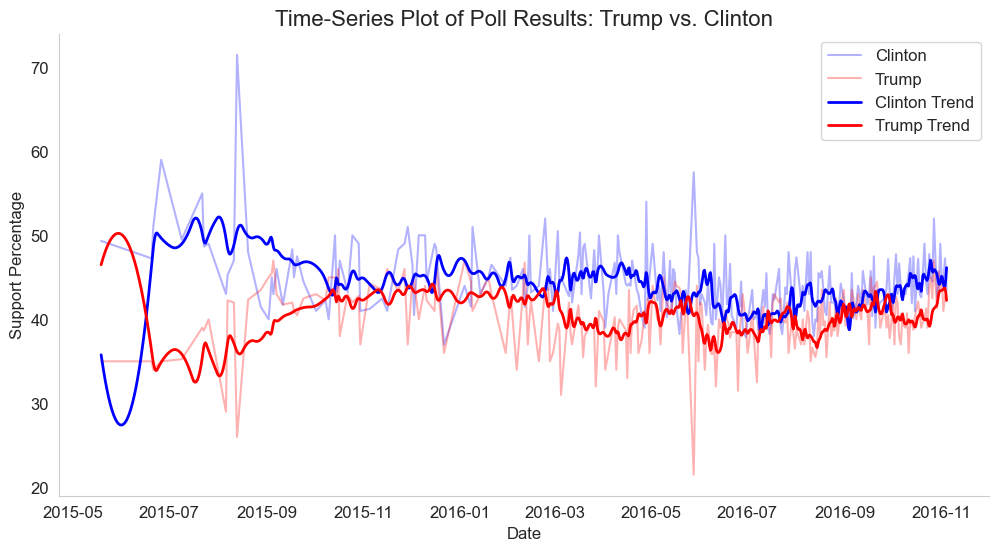

In [22]:
df = df.sort_values('Start Date')

window_size = 30 
df['Clinton_smooth'] = df['Clinton'].rolling(window=window_size, min_periods=1).mean()
df['Trump_smooth'] = df['Trump'].rolling(window=window_size, min_periods=1).mean()

plt.figure(figsize=(12, 6))

sns.lineplot(x='Start Date', y='Clinton', data=df, label='Clinton', ci=None, color='blue', alpha=0.3)
sns.lineplot(x='Start Date', y='Trump', data=df, label='Trump', ci=None, color='red', alpha=0.3)

def add_smooth_trend(x, y, color, label):
    x_numeric = pd.to_numeric(x)
    spline = make_interp_spline(x_numeric, y, k=2)

    x_smooth = np.linspace(x_numeric.min(), x_numeric.max(), 1000)
    y_smooth = spline(x_smooth)

    plt.plot(pd.to_datetime(x_smooth), y_smooth, color=color, label=label, linewidth=2)

df_unique = df.groupby('Start Date')[['Clinton_smooth', 'Trump_smooth']].mean().reset_index()

add_smooth_trend(df_unique['Start Date'], df_unique['Clinton_smooth'], color='blue', label='Clinton Trend')
add_smooth_trend(df_unique['Start Date'], df_unique['Trump_smooth'], color='red', label='Trump Trend')

plt.title('Time-Series Plot of Poll Results: Trump vs. Clinton', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Support Percentage', fontsize=12)
plt.legend()
plt.grid(False)
sns.despine()
plt.show()

## 5- Calculate Total Number of Voters Observed

In [25]:
total_voters = df['Number of Observations'].sum()
print(f"Total voters observed: {total_voters:,.0f}")

Total voters observed: 1,872,688


## 6- Calculate Estimated Proportions for Trump and Clinton

In [26]:
total_weighted_trump = (df['Trump'] * df['Number of Observations'] / 100).sum()
total_weighted_clinton = (df['Clinton'] * df['Number of Observations'] / 100).sum()

prop_trump = total_weighted_trump / total_voters
prop_clinton = total_weighted_clinton / total_voters

results = pd.DataFrame({
    'Candidate': ['Trump', 'Clinton'],
    'Estimated Proportion': [prop_trump, prop_clinton],
    'Percentage': [prop_trump * 100, prop_clinton * 100]
})
print(results)

  Candidate  Estimated Proportion  Percentage
0     Trump              0.404101   40.410127
1   Clinton              0.455289   45.528886


## 7- Compute 95% Confidence Intervals for Trump and Clinton Support


Total voters in all polls: 1,872,688.0

Estimated Proportions:
  Trump:    40.410% (95% CI: [40.340%, 40.480%])
  Clinton:  45.529% (95% CI: [45.458%, 45.600%])

Margins of Error:
  Trump:    ±0.070%
  Clinton:  ±0.071%

Standard Errors:
  Trump:    0.00036
  Clinton:  0.00036

Statistical Significance Check:
  CIs overlap? NO


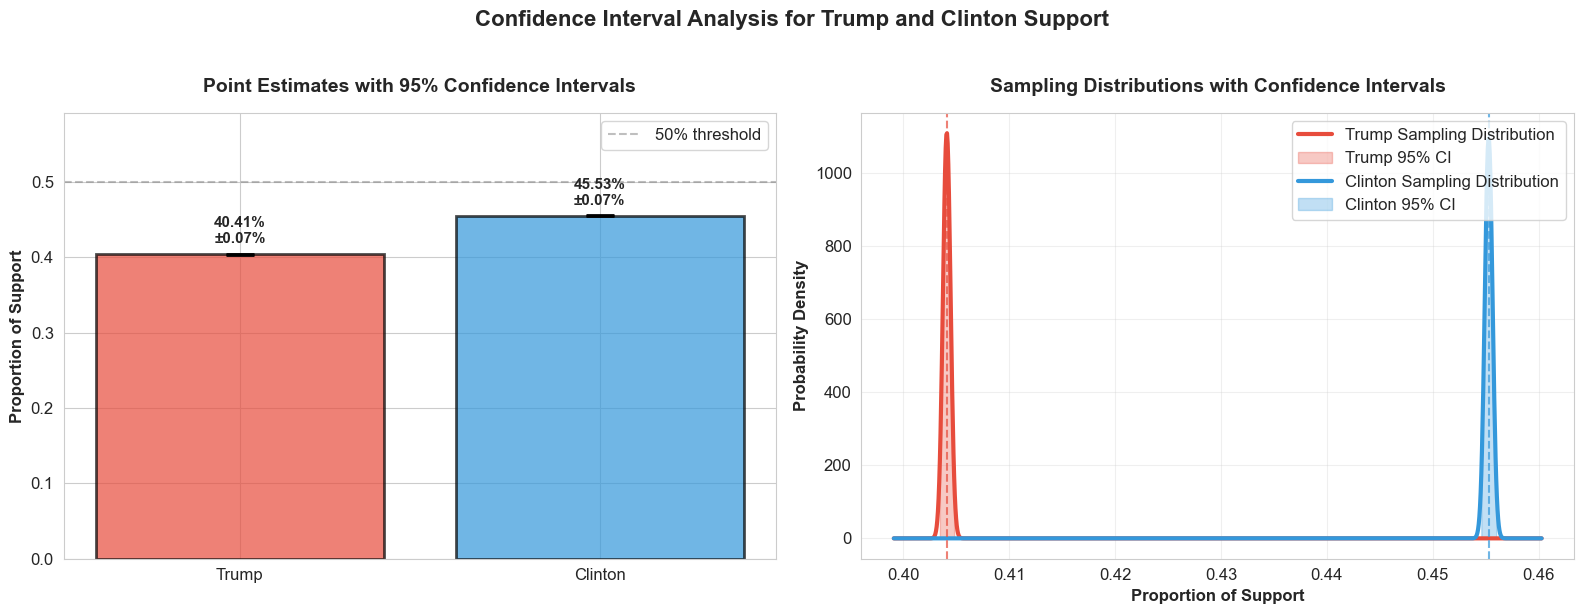

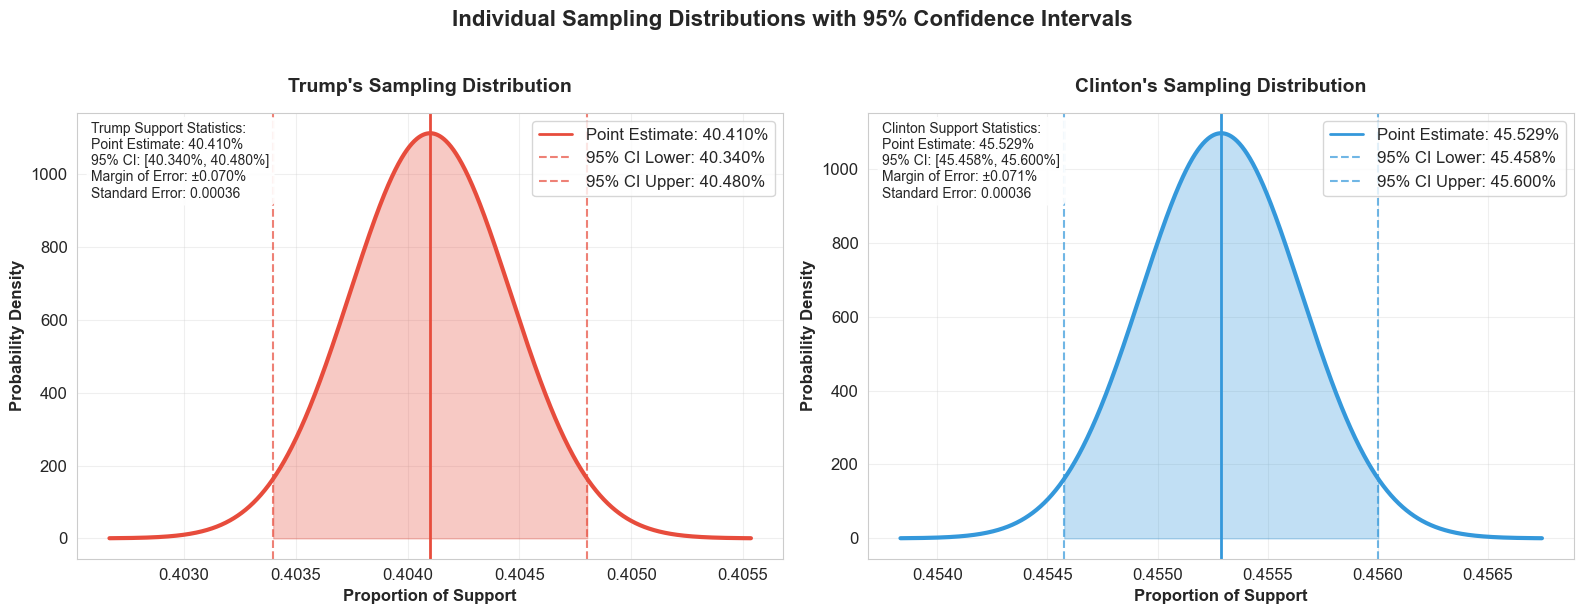

In [27]:
def compute_confidence_intervals(df):
    total_voters = df['Number of Observations'].sum()

    trump_counts = (df['Trump'] * df['Number of Observations'] / 100).sum()
    clinton_counts = (df['Clinton'] * df['Number of Observations'] / 100).sum()
    
    p_trump = trump_counts / total_voters
    p_clinton = clinton_counts / total_voters

    se_trump = np.sqrt(p_trump * (1 - p_trump) / total_voters)
    se_clinton = np.sqrt(p_clinton * (1 - p_clinton) / total_voters)

    z = stats.norm.ppf(0.975)  # 1.96
    
    ci_trump = (p_trump - z * se_trump, p_trump + z * se_trump)
    ci_clinton = (p_clinton - z * se_clinton, p_clinton + z * se_clinton)

    moe_trump = z * se_trump
    moe_clinton = z * se_clinton
    
    return {
        'total_voters': total_voters,
        'p_trump': p_trump,
        'p_clinton': p_clinton,
        'se_trump': se_trump,
        'se_clinton': se_clinton,
        'ci_trump': ci_trump,
        'ci_clinton': ci_clinton,
        'moe_trump': moe_trump,
        'moe_clinton': moe_clinton
    }

results = compute_confidence_intervals(df)

print(f"\nTotal voters in all polls: {results['total_voters']:,}")
print(f"\nEstimated Proportions:")
print(f"  Trump:    {results['p_trump']:.3%} (95% CI: [{results['ci_trump'][0]:.3%}, {results['ci_trump'][1]:.3%}])")
print(f"  Clinton:  {results['p_clinton']:.3%} (95% CI: [{results['ci_clinton'][0]:.3%}, {results['ci_clinton'][1]:.3%}])")
print(f"\nMargins of Error:")
print(f"  Trump:    ±{results['moe_trump']:.3%}")
print(f"  Clinton:  ±{results['moe_clinton']:.3%}")
print(f"\nStandard Errors:")
print(f"  Trump:    {results['se_trump']:.5f}")
print(f"  Clinton:  {results['se_clinton']:.5f}")

trump_lower, trump_upper = results['ci_trump']
clinton_lower, clinton_upper = results['ci_clinton']
overlap = max(trump_lower, clinton_lower) <= min(trump_upper, clinton_upper)

print(f"\nStatistical Significance Check:")
print(f"  CIs overlap? {'YES' if overlap else 'NO'}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confidence Interval Analysis for Trump and Clinton Support', 
             fontsize=16, fontweight='bold', y=1.02)

ax1 = axes[0]
candidates = ['Trump', 'Clinton']
proportions = [results['p_trump'], results['p_clinton']]
errors = [results['moe_trump'], results['moe_clinton']]
colors = ['#E74C3C', '#3498DB']

bars = ax1.bar(candidates, proportions, color=colors, alpha=0.7, 
               edgecolor='black', linewidth=2, yerr=errors, 
               capsize=10, error_kw={'elinewidth': 2, 'capthick': 2})

ax1.set_ylabel('Proportion of Support', fontsize=12, fontweight='bold')
ax1.set_title('Point Estimates with 95% Confidence Intervals', 
              fontsize=14, fontweight='bold', pad=15)
ax1.set_ylim(0, max(proportions) * 1.3)

for i, (bar, prop, err) in enumerate(zip(bars, proportions, errors)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + err + 0.01,
            f'{prop:.2%}\n±{err:.2%}', ha='center', va='bottom', 
            fontsize=11, fontweight='bold')

ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
ax1.legend()

ax2 = axes[1]
x = np.linspace(min(results['p_trump'], results['p_clinton']) - 0.005, 
                max(results['p_trump'], results['p_clinton']) + 0.005, 1000)

trump_dist = stats.norm.pdf(x, results['p_trump'], results['se_trump'])
ax2.plot(x, trump_dist, color='#E74C3C', linewidth=3, label='Trump Sampling Distribution')
ax2.fill_between(x, trump_dist, where=(x >= results['ci_trump'][0]) & (x <= results['ci_trump'][1]), 
                 color='#E74C3C', alpha=0.3, label='Trump 95% CI')

clinton_dist = stats.norm.pdf(x, results['p_clinton'], results['se_clinton'])
ax2.plot(x, clinton_dist, color='#3498DB', linewidth=3, label='Clinton Sampling Distribution')
ax2.fill_between(x, clinton_dist, where=(x >= results['ci_clinton'][0]) & (x <= results['ci_clinton'][1]), 
                 color='#3498DB', alpha=0.3, label='Clinton 95% CI')

ax2.set_xlabel('Proportion of Support', fontsize=12, fontweight='bold')
ax2.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax2.set_title('Sampling Distributions with Confidence Intervals', 
              fontsize=14, fontweight='bold', pad=15)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

ax2.axvline(results['p_trump'], color='#E74C3C', linestyle='--', alpha=0.7)
ax2.axvline(results['p_clinton'], color='#3498DB', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))
fig2.suptitle('Individual Sampling Distributions with 95% Confidence Intervals', 
              fontsize=16, fontweight='bold', y=1.02)

x_trump = np.linspace(results['p_trump'] - 4*results['se_trump'], 
                      results['p_trump'] + 4*results['se_trump'], 1000)
trump_dist = stats.norm.pdf(x_trump, results['p_trump'], results['se_trump'])

ax3.plot(x_trump, trump_dist, color='#E74C3C', linewidth=3)
ax3.fill_between(x_trump, trump_dist, 
                 where=(x_trump >= results['ci_trump'][0]) & (x_trump <= results['ci_trump'][1]), 
                 color='#E74C3C', alpha=0.3)

ax3.axvline(results['p_trump'], color='#E74C3C', linestyle='-', linewidth=2, 
           label=f'Point Estimate: {results["p_trump"]:.3%}')
ax3.axvline(results['ci_trump'][0], color='#E74C3C', linestyle='--', linewidth=1.5, alpha=0.7, 
           label=f'95% CI Lower: {results["ci_trump"][0]:.3%}')
ax3.axvline(results['ci_trump'][1], color='#E74C3C', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'95% CI Upper: {results["ci_trump"][1]:.3%}')

ax3.set_xlabel('Proportion of Support', fontsize=12, fontweight='bold')
ax3.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax3.set_title("Trump's Sampling Distribution", fontsize=14, fontweight='bold', pad=15)
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

trump_stats = f"""Trump Support Statistics:
Point Estimate: {results['p_trump']:.3%}
95% CI: [{results['ci_trump'][0]:.3%}, {results['ci_trump'][1]:.3%}]
Margin of Error: ±{results['moe_trump']:.3%}
Standard Error: {results['se_trump']:.5f}"""
ax3.text(0.02, 0.98, trump_stats, transform=ax3.transAxes, fontsize=10, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

x_clinton = np.linspace(results['p_clinton'] - 4*results['se_clinton'], 
                       results['p_clinton'] + 4*results['se_clinton'], 1000)
clinton_dist = stats.norm.pdf(x_clinton, results['p_clinton'], results['se_clinton'])

ax4.plot(x_clinton, clinton_dist, color='#3498DB', linewidth=3)
ax4.fill_between(x_clinton, clinton_dist, 
                 where=(x_clinton >= results['ci_clinton'][0]) & (x_clinton <= results['ci_clinton'][1]), 
                 color='#3498DB', alpha=0.3)

ax4.axvline(results['p_clinton'], color='#3498DB', linestyle='-', linewidth=2, 
           label=f'Point Estimate: {results["p_clinton"]:.3%}')
ax4.axvline(results['ci_clinton'][0], color='#3498DB', linestyle='--', linewidth=1.5, alpha=0.7, 
           label=f'95% CI Lower: {results["ci_clinton"][0]:.3%}')
ax4.axvline(results['ci_clinton'][1], color='#3498DB', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'95% CI Upper: {results["ci_clinton"][1]:.3%}')

ax4.set_xlabel('Proportion of Support', fontsize=12, fontweight='bold')
ax4.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax4.set_title("Clinton's Sampling Distribution", fontsize=14, fontweight='bold', pad=15)
ax4.legend(loc='upper right')
ax4.grid(True, alpha=0.3)

clinton_stats = f"""Clinton Support Statistics:
Point Estimate: {results['p_clinton']:.3%}
95% CI: [{results['ci_clinton'][0]:.3%}, {results['ci_clinton'][1]:.3%}]
Margin of Error: ±{results['moe_clinton']:.3%}
Standard Error: {results['se_clinton']:.5f}"""
ax4.text(0.02, 0.98, clinton_stats, transform=ax4.transAxes, fontsize=10, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.show()


## 8- Hypothesis Test for Spread

In [28]:
total_voters = df['Number of Observations'].sum()
clinton_counts = (df['Clinton'] * df['Number of Observations'] / 100).sum()
p_hat = clinton_counts / total_voters 

print("=" * 60)
print("SPREAD ANALYSIS: CLINTON VS TRUMP")
print("=" * 60)

N = total_voters
se_p = math.sqrt(p_hat * (1 - p_hat) / N)

d_hat = 2 * p_hat - 1
z = 1.96
margin_error = z * 2 * se_p

ci_lower = d_hat - margin_error
ci_upper = d_hat + margin_error

print(f"\n(a) 95% CONFIDENCE INTERVAL FOR SPREAD d:")
print(f"    Total voters (N): {N:,}")
print(f"    Estimated p (Clinton support): {p_hat:.4f} ({p_hat:.2%})")
print(f"    Estimated spread d = 2p - 1: {d_hat:.4f} ({d_hat:.2%})")
print(f"    Standard error of p: {se_p:.6f}")
print(f"    Standard error of d: {2*se_p:.6f}")
print(f"    Margin of error: ±{margin_error:.4f}")
print(f"    95% CI for d: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"    In percentage: [{ci_lower:.2%}, {ci_upper:.2%}]")

print(f"\n(b) HYPOTHESIS TEST:")
print(f"    H₀: d = 0 (race is tied)")
print(f"    H₁: d ≠ 0 (one candidate leads)")

Z = d_hat / (2 * se_p)

p_value = 2 * (1 - stats.norm.cdf(abs(Z)))

print(f"    Test statistic (Z): {Z:.4f}")
print(f"    P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"    Decision: REJECT H₀ at α = {alpha}")
    if d_hat > 0:
        print(f"    Conclusion: Clinton leads Trump significantly (p < {alpha})")
    else:
        print(f"    Conclusion: Trump leads Clinton significantly (p < {alpha})")
else:
    print(f"    Decision: FAIL TO REJECT H₀ at α = {alpha}")
    print(f"    Conclusion: No significant difference (race is statistically tied)")

print(f"\nALTERNATIVE CHECK USING CONFIDENCE INTERVAL:")
if ci_lower > 0:
    print(f"    Entire CI > 0 → Clinton leads significantly")
elif ci_upper < 0:
    print(f"    Entire CI < 0 → Trump leads significantly")
else:
    print(f"    CI contains 0 → No significant difference")

print("\n" + "=" * 60)


SPREAD ANALYSIS: CLINTON VS TRUMP

(a) 95% CONFIDENCE INTERVAL FOR SPREAD d:
    Total voters (N): 1,872,688.0
    Estimated p (Clinton support): 0.4553 (45.53%)
    Estimated spread d = 2p - 1: -0.0894 (-8.94%)
    Standard error of p: 0.000364
    Standard error of d: 0.000728
    Margin of error: ±0.0014
    95% CI for d: [-0.0908, -0.0880]
    In percentage: [-9.08%, -8.80%]

(b) HYPOTHESIS TEST:
    H₀: d = 0 (race is tied)
    H₁: d ≠ 0 (one candidate leads)
    Test statistic (Z): -122.8632
    P-value: 0.0000
    Decision: REJECT H₀ at α = 0.05
    Conclusion: Trump leads Clinton significantly (p < 0.05)

ALTERNATIVE CHECK USING CONFIDENCE INTERVAL:
    Entire CI < 0 → Trump leads significantly



# Drug Safety Test


In [ ]:
import pandas as pd
from scipy import stats

### Loading the dataset

In [ ]:
DataFrame = pd.read_csv('drug_safety.csv')
DataFrame = DataFrame.dropna()
DataFrame.head(5)

,age,sex,trx,week,wbc,rbc,adverse_effects,num_effects
0,62,male,Drug,0,7.3,5.1,No,0
2,62,male,Drug,12,5.6,5.0,No,0
4,62,male,Drug,2,6.6,5.1,No,0
6,62,male,Drug,4,6.9,5.2,Yes,1
7,62,male,Drug,8,7.1,5.0,Yes,1


### Displaying main statistics for each numerical column

In [ ]:
print("main Statistics for age:")
DataFrame["age"].describe()

main Statistics for age:


count    9127.000000
mean       64.007670
std         8.847711
min        39.000000
25%        58.000000
50%        65.000000
75%        71.000000
max        84.000000
Name: age, dtype: float64

In [ ]:
print("main Statistics for week:")
DataFrame["week"].describe()

main Statistics for week:


count    9127.000000
mean        4.985428
std         4.375397
min         0.000000
25%         2.000000
50%         4.000000
75%         8.000000
max        20.000000
Name: week, dtype: float64

In [ ]:
print("main Statistics for white blood cells:")
DataFrame["wbc"].describe()

main Statistics for white blood cells:


count    9127.000000
mean        7.340331
std         1.996645
min         1.800000
25%         6.000000
50%         7.100000
75%         8.400000
max        26.500000
Name: wbc, dtype: float64

In [ ]:
print("main Statistics for red blood cells:")
DataFrame["rbc"].describe()

main Statistics for red blood cells:


count    9127.000000
mean        4.672784
std         0.458520
min         2.100000
25%         4.400000
50%         4.700000
75%         5.000000
max         7.600000
Name: rbc, dtype: float64

In [ ]:
print("main Statistics for num of effects:")
DataFrame["num_effects"].describe()

main Statistics for num of effects:


count    9127.000000
mean        0.100800
std         0.322178
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         3.000000
Name: num_effects, dtype: float64

### Grouping the required elements

In [ ]:
DataFrame["adverse_effects"] = DataFrame["adverse_effects"].replace({'Yes': 1, 'No': 0})
grouped = DataFrame.groupby('trx')[['wbc', 'rbc']]
grouped.describe()

C:\Users\Public\Documents\iSkysoft\CreatorTemp\ipykernel_3500\2188421163.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  DataFrame["adverse_effects"] = DataFrame["adverse_effects"].replace({'Yes': 1, 'No': 0})


wbc                                                         rbc  \
          count      mean       std  min  25%   50%  75%        max   count   
trx                                                                           
Drug     6011.0  7.330461  2.008941  1.8  6.0  7.00  8.4  26.500000  6011.0   
Placebo  3116.0  7.359371  1.972890  3.0  6.0  7.15  8.4  23.799999  3116.0   

                                                      
             mean       std  min  25%  50%  75%  max  
trx                                                   
Drug     4.679130  0.454990  2.7  4.4  4.7  5.0  7.5  
Placebo  4.660542  0.465083  2.1  4.4  4.7  5.0  7.6

In [ ]:
grouped2 = DataFrame.groupby('trx')[['num_effects', 'adverse_effects']]
grouped2.describe()

num_effects                                               \
              count      mean       std  min  25%  50%  75%  max   
trx                                                                
Drug         6011.0  0.102479  0.325529  0.0  0.0  0.0  0.0  3.0   
Placebo      3116.0  0.097561  0.315639  0.0  0.0  0.0  0.0  3.0   

        adverse_effects                                               
                  count      mean       std  min  25%  50%  75%  max  
trx                                                                   
Drug             6011.0  0.095991  0.294603  0.0  0.0  0.0  0.0  1.0  
Placebo          3116.0  0.092105  0.289221  0.0  0.0  0.0  0.0  1.0

### Statistical test for each metric 

In [ ]:
drug_wbc = grouped.get_group("Drug")["wbc"]
placebo_wbc = grouped.get_group("Placebo")["wbc"]
t_stat, p_value_wbc = stats.ttest_ind(drug_wbc, placebo_wbc, equal_var=True, alternative='two-sided')
print(f"P value for white blood cells: {p_value_wbc}")

P value for white blood cells: 0.5118984779930507


In [ ]:
drug_rbc = grouped.get_group("Drug")["rbc"]
placebo_rbc = grouped.get_group("Placebo")["rbc"]
t_stat, p_value_rbc = stats.ttest_ind(drug_rbc, placebo_rbc, equal_var=True, alternative='two-sided')
print(f"P value for red blood cells: {p_value_rbc}")

P value for red blood cells: 0.06629268892144846


In [ ]:
drug_num_effects = grouped2.get_group("Drug")["num_effects"]
placebo_num_effects = grouped2.get_group("Placebo")["num_effects"]
t_stat, p_value_num = stats.ttest_ind(drug_num_effects, placebo_num_effects, equal_var=True, alternative='two-sided')
print(f"P value for num effects: {p_value_num}")

P value for num effects: 0.48928880210465087


In [ ]:
drug_adverse_effects = grouped2.get_group("Drug")["adverse_effects"]
placebo_adverse_effects = grouped2.get_group("Placebo")["adverse_effects"]
t_stat, p_value_adv = stats.ttest_ind(drug_adverse_effects, placebo_adverse_effects, equal_var=True, alternative='two-sided')
print(f"P value for adverse effects: {p_value_adv}")

P value for adverse effects: 0.5477305282650342


###  T test results 
### -interpretation for metrics *num effects, adverse effects and white blood cells*:
Because all of their p-values are above 0.48, which is much larger than standard significance levels (5% or 10%), we fail to reject the null hypothesis.



### -interpretation for the *red blood cell* metric:
    for the significant level of 5%, this p value which is around 6.6% is higher than the significant level so we still reject the null hypothesis, but because its way closer to 5%, this means the data has weaker information to reject it.
    
    But when we increase the significance level to 10%, the p-value ($0.066 < 0.10$) becomes smaller than the threshold, so the null hypothesis is rejected.

    Increasing the significance level makes our test less strict. It means we are willing to accept a higher risk of a Type I Error (False Positive). Conversely, decreasing the significance level makes the test stricter, reducing Type I errors but increasing the risk of a Type II Error (False Negative).

### Scipy questions 
### -Alternative argument: 
This argument defines our alternative hypothesis. It specifies whether we are testing if the mean of group 1 is strictly greater than, strictly less than, or simply not equal to the mean of group 2 (two-sided test).

Because our null hypothesis states there is no difference between the means, we don't care if one is bigger or smaller than the other. We just want to know if they are unequal, so we used 'two-sided' for each test.

### -Equal_var argument:
    This determines whether we assume the two populations have the exact same variance. If equal_var=True (the default in Scipy), Student’s t-test is performed. If equal_var=False, Welch’s t-test is performed.


    
### Student’s t-test (Equal Variances)
$$
t = \frac{\bar{X}_1 - \bar{X}_2}{S_p \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}}
$$

where:

$$
S_p = \sqrt{\frac{(n_1 - 1) S_1^2 + (n_2 - 1) S_2^2}{n_1 + n_2 - 2}}
$$


### Welch’s t-test (not equal Variances)
$$
t = \frac{\bar{X}_1 - \bar{X}_2}{\sqrt{\frac{S_1^2}{n_1} + \frac{S_2^2}{n_2}}}
$$